# Radio Interferometry Simulation with pyuvsim

This script performs radio interferometry simulations using pyuvsim and analyzes
the resulting visibility data. The workflow includes:

1. Path configuration and validation
2. Observation parameter inspection
3. Antenna layout visualization
4. Sky model loading and visualization
5. Frequency and time sampling analysis
6. UV coverage computation
7. Simulation execution with MPI
8. Visibility comparison and residual analysis

Author: Quentin Gueuning

Requirements: pyuvsim, pyuvdata, pyradiosky, healpy, astropy, numpy, matplotlib


## Imports



In [ ]:
import subprocess
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import yaml
from astropy.time import Time
from pyradiosky import SkyModel
from pyuvdata import UVData

from valska.external_tools import pyuvsim
from valska.notebook_helpers import extract_vis, unpack_shape
from valska.utils import get_repo_root, read_yaml

## File Path Configuration


Automatically set up all necessary paths based on the project structure.  
The paths point to:

- Observation parameter YAML files  
- Telescope configuration files (layout, beam models)  
- Sky catalog files


In [2]:
# Get root directory of repository
REPO_ROOT = get_repo_root()
TEMPLATES = REPO_ROOT / "src/valska/external_tools/pyuvsim/templates"

# Simulation config files
OBSPARAM_YAML = TEMPLATES / "fov-19.4-oscar-sm.yml"
TELESCOPE_CSV = TEMPLATES / "telescope_config/hex-37-14.6m.csv"
BEAM_YAML = TEMPLATES / "telescope_config/hex-37-14.6m-gauss-fwhm9.3.yml"
SKYH5_PATH = (
    TEMPLATES
    / "catalog_files/gleam-field-1-158.30-167.10-MHz-nf-38-fov-19.4-pld-mean-2.82-std-0.19.skyh5"
)

# Project root - this is needed later to run the simulation!
proj_root = ""

# Verify and display paths
print("Paths set:")
print("obsparam:", OBSPARAM_YAML)
print("layout:", TELESCOPE_CSV)
print("beam:", BEAM_YAML)
print("sky:", SKYH5_PATH)

Paths set:
obsparam: /home/epolehampton/ValSKA-HERA-beam-FWHM/src/valska/external_tools/pyuvsim/templates/fov-19.4-oscar-sm.yml
layout: /home/epolehampton/ValSKA-HERA-beam-FWHM/src/valska/external_tools/pyuvsim/templates/telescope_config/hex-37-14.6m.csv
beam: /home/epolehampton/ValSKA-HERA-beam-FWHM/src/valska/external_tools/pyuvsim/templates/telescope_config/hex-37-14.6m-gauss-fwhm9.3.yml
sky: /home/epolehampton/ValSKA-HERA-beam-FWHM/src/valska/external_tools/pyuvsim/templates/catalog_files/gleam-field-1-158.30-167.10-MHz-nf-38-fov-19.4-pld-mean-2.82-std-0.19.skyh5


## Observation Parameter Inspection

Load the observation parameter YAML file and display its structure.  
This file contains:

- Filing information (output paths)  
- Observation timing and frequency setup  
- Telescope configuration references  
- Sky model and catalog specifications  
- Beam model parameters


In [ ]:
if not OBSPARAM_YAML.exists():
    print(f"WARNING: obsparam YAML not found at {OBSPARAM_YAML}.")
else:
    obsparam = read_yaml(OBSPARAM_YAML)
    print("Top-level keys in obsparam: ", list(obsparam.keys()))

    # Print helpful sections
    for key in (
        "filing",
        "observation",
        "telescope",
        "sky_model",
        "catalogs",
        "beams",
    ):
        if key in obsparam:
            print(f"\n--- {key} ---")
            print(yaml.dump(obsparam[key], default_flow_style=False))

Top-level keys in obsparam:  ['filing', 'freq', 'sources', 'telescope', 'time', 'select']

--- filing ---
clobber: true
outdir: outputs/
outfile_name: gleam-field-1-pld-mean-2.82-std-0.19-nf-38-nt-34-dt-11s-fov-19.4deg-gauss
output_format: uvh5


--- telescope ---
array_layout: ./telescope_config/hex-37-14.6m.csv
telescope_config_name: ./telescope_config/hex-37-14.6m-gauss-fwhm9.3.yml



## Antenna Layout Visualization

Parse the telescope layout CSV file and visualize antenna positions in  
East-North-Up (ENU) coordinates. The layout file contains columns:  
`Name, Number, BeamID, E, N, U`

Reading layout CSV: /home/epolehampton/ValSKA-HERA-beam-FWHM/src/valska/external_tools/pyuvsim/templates/telescope_config/hex-37-14.6m.csv
Parsed 37 antennas


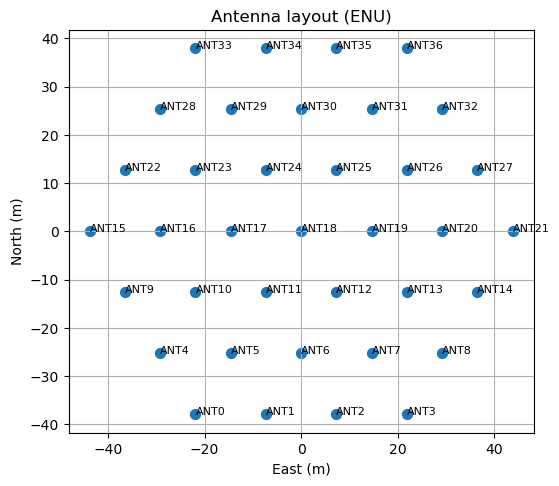

In [ ]:
if TELESCOPE_CSV.exists():
    print("Reading layout CSV:", TELESCOPE_CSV)

    # Load CSV with tab delimiter
    data = np.genfromtxt(
        TELESCOPE_CSV,
        delimiter="\t",
        dtype=None,
        names=True,
        encoding="utf-8",
    )

    # Extract antenna positions
    names = data["Name"]
    east = data["E"]
    north = data["N"]
    up = data["U"]

    print(f"Parsed {len(east)} antennas")

    # Plot antenna layout in ENU frame
    plt.figure(figsize=(6, 6))
    plt.scatter(east, north, s=50)
    for i, n in enumerate(names):
        plt.text(east[i], north[i], n, fontsize=8)
    plt.xlabel("East (m)")
    plt.ylabel("North (m)")
    plt.title("Antenna layout (ENU)")
    plt.gca().set_aspect("equal", "box")
    plt.grid(True)
    plt.show()

else:
    print("Layout CSV not found. Check TELESCOPE_CSV path.")

## Beam Configuration
### GaussianBeam width conventions: electric field vs power

In the `GaussianBeam` function of the analytic_beam class in the pyuvdata package, the beam is fundamentally modeled at the level of the
electric field (voltage response), not directly at the level of power.

The analytic Gaussian beam is defined as an electric-field (voltage) pattern:

$$
E(\theta) = E_0 \exp\!\left(-\frac{\theta^2}{2\sigma_E^2}\right)
$$

where $\theta$ is the zenith angle and $\sigma_E$ is the electric-field standard deviation.
The corresponding power beam is:

$$
P(\theta) = |E(\theta)|^2
          = P_0 \exp\!\left(-\frac{\theta^2}{\sigma_E^2}\right)
$$

This is also a Gaussian, but with a smaller standard deviation:

$$
\sigma_P = \frac{\sigma_E}{\sqrt{2}}
$$

Thus, the power beam is narrower than the electric-field beam and half-power beam width (HBPW / FWHM) is defined on $P(\theta)$, not $E(\theta)$

### Relation between FWHM and σ

For any Gaussian:

$$
\mathrm{FWHM} = 2\sqrt{2\ln 2}\,\sigma \approx 2.355\,\sigma
$$

So for the power beam:

$$
\sigma_P = \frac{\mathrm{FWHM}}{2.355}
$$

and for the electric field:

$$
\sigma_E = \sqrt{2}\,\sigma_P
$$

### Example: HERA's primary beam at 150 MHz

Load and display beam YAML. We'll print the std of the Gaussian beam.

In [ ]:
if BEAM_YAML.exists():
    beamcfg = read_yaml(BEAM_YAML)
    print("Beam YAML contents:")
    print(yaml.dump(beamcfg))
else:
    print("Beam YAML not found at", BEAM_YAML)

Beam YAML contents:
beam_paths:
  0:
    sigma: 0.09754450727124656
    type: gaussian
telescope_location: (-30.72152777777791, 21.428305555555557, 1073.0000000093132)
telescope_name: Hex37-14.6m



In [6]:
# -------------------------------
# Beam YAML sigma (electric-field)
# -------------------------------
sigma_field_rad = beamcfg["beam_paths"][0]["sigma"]
sigma_field_deg = np.rad2deg(sigma_field_rad)

# -------------------------------
# Compute corresponding power beam sigma
# -------------------------------
# sigma_P = sigma_E / sqrt(2)
sigma_power_rad = sigma_field_rad / np.sqrt(2)
sigma_power_deg = np.rad2deg(sigma_power_rad)

# -------------------------------
# Compute FWHM of power beam
# FWHM = 2*sqrt(2*ln2)*sigma
# -------------------------------
fwhm_factor = 2 * np.sqrt(2 * np.log(2))
FWHM_power_rad = sigma_power_rad * fwhm_factor
FWHM_power_deg = sigma_power_deg * fwhm_factor

# -------------------------------
# Print results
# -------------------------------
print("=== Beam width from YAML sigma (electric-field) ===")
print(
    f"Electric-field sigma       : {sigma_field_deg:.2f} deg  ({sigma_field_rad:.4f} rad)"
)
print(
    f"Power-beam sigma           : {sigma_power_deg:.2f} deg  ({sigma_power_rad:.4f} rad)"
)
print(
    f"Power-beam FWHM (HBPW)     : {FWHM_power_deg:.2f} deg  ({FWHM_power_rad:.4f} rad)"
)

=== Beam width from YAML sigma (electric-field) ===
Electric-field sigma       : 5.59 deg  (0.0975 rad)
Power-beam sigma           : 3.95 deg  (0.0690 rad)
Power-beam FWHM (HBPW)     : 9.31 deg  (0.1624 rad)


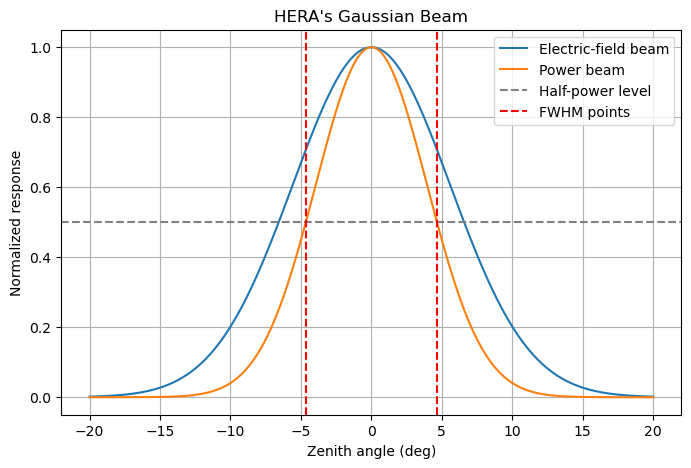

In [7]:
# -------------------------------
# Plot Gaussian beams
# -------------------------------
theta_deg = np.linspace(-20, 20, 2000)  # angle grid in degrees
theta_rad = np.deg2rad(theta_deg)

E = np.exp(-(theta_rad**2) / (2 * sigma_field_rad**2))  # electric-field beam
P = E**2  # power beam

# Half-power points for power beam
half_power = 0.5
indices = np.where(P >= half_power)[0]
theta_minus = theta_deg[indices[0]]
theta_plus = theta_deg[indices[-1]]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(theta_deg, E, label="Electric-field beam")
plt.plot(theta_deg, P, label="Power beam")
plt.axhline(0.5, color="gray", linestyle="--", label="Half-power level")
plt.axvline(theta_minus, color="red", linestyle="--", label="FWHM points")
plt.axvline(theta_plus, color="red", linestyle="--")

plt.xlabel("Zenith angle (deg)")
plt.ylabel("Normalized response")
plt.title("HERA's Gaussian Beam")
plt.legend()
plt.grid(True)
plt.show()

## Sky Model Visualization


Load the sky model catalog in SKYH5 format and visualize source positions  
in equatorial coordinates (RA/Dec). 

Found sky file at /home/epolehampton/ValSKA-HERA-beam-FWHM/src/valska/external_tools/pyuvsim/templates/catalog_files/gleam-field-1-158.30-167.10-MHz-nf-38-fov-19.4-pld-mean-2.82-std-0.19.skyh5
Number of sources: 4996


Parameter skycoord not found in skyh5 file. This skyh5 file was written by an older version of pyradiosky. Consider re-writing this file to ensure future compatibility
No frame available in this file, assuming 'icrs'. Consider re-writing this file to ensure future compatibility.


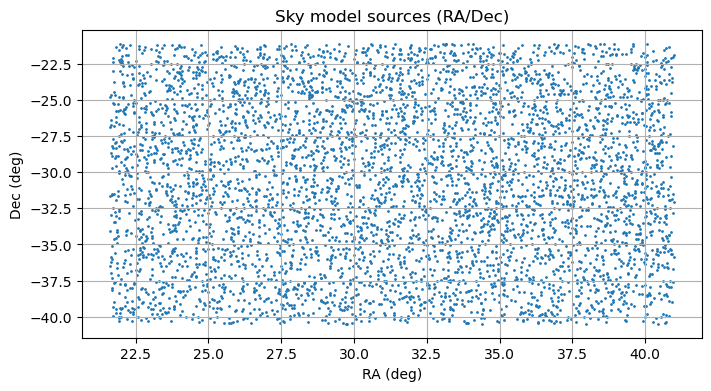

In [ ]:
# Verify sky file exists
sky_present = SKYH5_PATH.exists()
if sky_present:
    print("Found sky file at", SKYH5_PATH)

    # Load SkyModel from HDF5
    skym = SkyModel()
    skym.read_skyh5(SKYH5_PATH)
    print("Number of sources:", skym.Ncomponents)

    # Extract source coordinates
    ra, dec = skym.get_lon_lat()
    ra_deg = ra.to("deg").value
    dec_deg = dec.to("deg").value

    # Plot source distribution on sky
    plt.figure(figsize=(8, 4))
    plt.scatter(ra_deg, dec_deg, s=1)
    plt.xlabel("RA (deg)")
    plt.ylabel("Dec (deg)")
    plt.title("Sky model sources (RA/Dec)")
    plt.grid(True)
    plt.show()
else:
    print("Sky file not found, create a dummy catalogue instead.")

## Frequency Array Visualization


Plot the frequency channels used in the simulation.


Number of frequency channels: 38


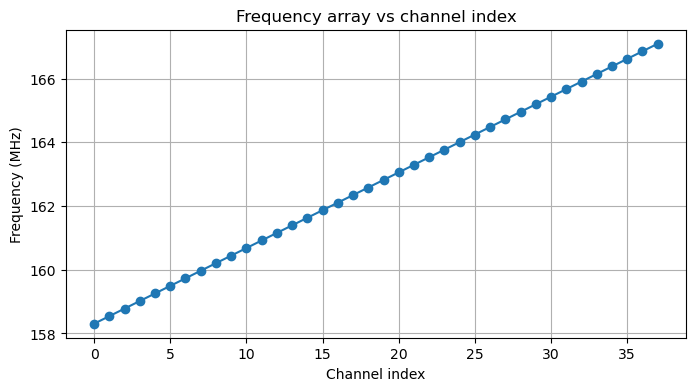

In [9]:
if obsparam and "freq" in obsparam:
    f = obsparam["freq"]
    N = int(f["Nfreqs"])
    start = f["start_freq"]
    chanw = f["channel_width"]

    # Compute frequency array
    freqs = start + chanw * np.arange(N)

    print(f"Number of frequency channels: {len(freqs)}")

    # Plot frequency vs channel index
    plt.figure(figsize=(8, 4))
    plt.plot(np.arange(len(freqs)), freqs / 1e6, marker="o", color="C0")
    plt.xlabel("Channel index")
    plt.ylabel("Frequency (MHz)")
    plt.title("Frequency array vs channel index")
    plt.grid(True)
    plt.show()
else:
    print("No frequency information found in obsparam.")

## Observation Time Array


Visualize the time sampling of the observation. Times are stored as Julian  
Dates (JD) and converted to UTC for display.

Number of time samples: 34


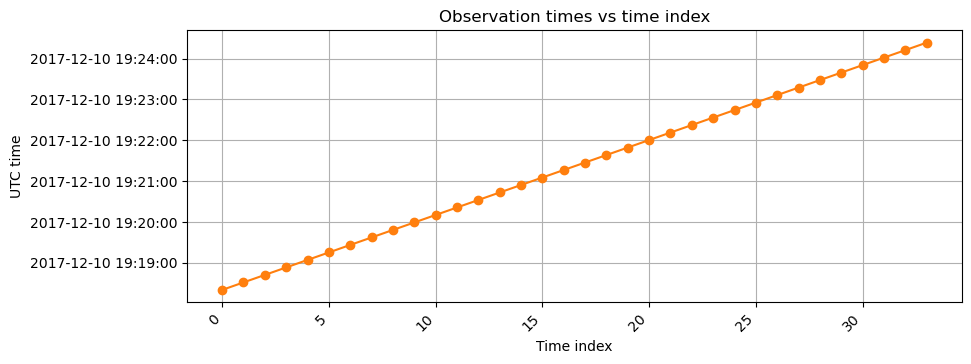

In [10]:
if obsparam and "time" in obsparam and "time_array" in obsparam["time"]:
    times = np.array(obsparam["time"]["time_array"])
    times_utc = Time(times, format="jd").to_datetime()
    print(f"Number of time samples: {len(times_utc)}")

    # Plot time array with proper UTC formatting
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(np.arange(len(times_utc)), times_utc, marker="o", color="C1")

    ax.set_xlabel("Time index")
    ax.set_ylabel("UTC time")
    ax.set_title("Observation times vs time index")
    ax.grid(True)

    # Format y-axis as full datetime
    ax.yaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M:%S"))
    fig.autofmt_xdate(rotation=45)

    plt.show()
else:
    print("No time array found in obsparam.")

## UV-Plane Coverage

Plot the (u, v) positions of selected baselines in the UV plane.  

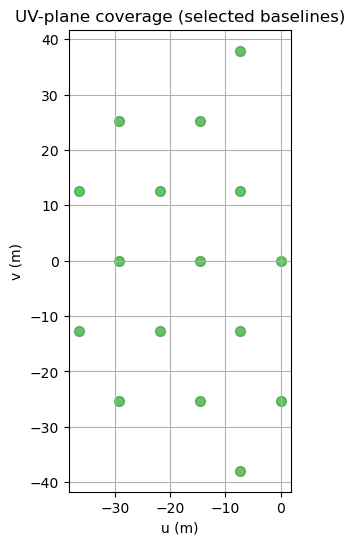

In [11]:
# Extract selected baselines from obsparam
sel_bls = []
if obsparam and "select" in obsparam and "bls" in obsparam["select"]:
    sel_bls = eval(obsparam["select"]["bls"])

if sel_bls:
    # Compute baseline vectors
    bls = np.array(
        [[east[i] - east[j], north[i] - north[j]] for i, j in sel_bls]
    )

    # Plot UV coverage
    plt.figure(figsize=(6, 6))
    plt.scatter(bls[:, 0], bls[:, 1], s=50, color="C2", alpha=0.7)
    plt.xlabel("u (m)")
    plt.ylabel("v (m)")
    plt.title("UV-plane coverage (selected baselines)")
    plt.grid(True)
    plt.gca().set_aspect("equal")
    plt.show()
else:
    print("No selected baselines defined in obsparam.")

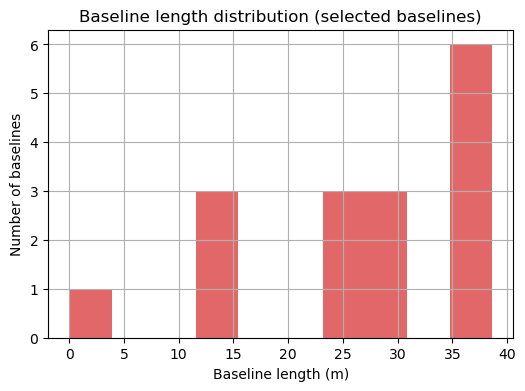

In [12]:
if sel_bls:
    # Compute baseline lengths
    bl_lengths = np.linalg.norm(bls, axis=1)

    # Plot histogram of baseline lengths
    plt.figure(figsize=(6, 4))
    plt.hist(bl_lengths, bins=10, color="C3", alpha=0.7)
    plt.xlabel("Baseline length (m)")
    plt.ylabel("Number of baselines")
    plt.title("Baseline length distribution (selected baselines)")
    plt.grid(True)
    plt.show()

## Simulation Execution

Run the pyuvsim simulation using the valska pyuvsim module. This module ensures that the output is compatible with further steps in the validation pipeline (e.g. BayesEoR) and that metadata and provenance information is saved. The module should be run on a Slurm cluster.

In order to run the pyuvsim module (see [pyuvsim workflow documentation](https://valska-hera-beam-fwhm.readthedocs.io/en/latest/workflows/pyuvsim_cli_examples.html)),

* Clone pyuvsim locally in a location you control from the repository on GitHub (git clone https://github.com/RadioAstronomySoftwareGroup/pyuvsim)
* Inside the cloned repository, create and activate a pyuvsim virtual environment, and install pyuvsim itself (`pip install .`)
* Copy `config/runtime_paths.example.yaml` to `config/runtime_paths.yaml` in your ValSKA repository and set
  * `results_root` - this sets the root directory for the pyuvsim run outputs
  * the pyuvsim conda environment configuration and `conda_sh` file location
  * any site-level Slurm defaults required by your cluster in `pyuvsim.slurm_defaults`

The simulation computes complex visibilities for each baseline, time,  
frequency, and polarization based on the sky model and instrument configuration.

In [ ]:
# Check runtime_paths.yaml exists
runtime_paths_dir = (REPO_ROOT / "config" / "runtime_paths.yaml").resolve()
if runtime_paths_dir.exists():
    print("Found runtime_paths: ", runtime_paths_dir)
    runtime_paths = read_yaml(runtime_paths_dir)
else:
    print("You need to create and fill a runtime_paths.yaml file!")

Found runtime_paths:  /home/epolehampton/ValSKA-HERA-beam-FWHM/config/runtime_paths.yaml


In [60]:
# Parameters needed to set up the run directory
beam_model = "achromatic_Gaussian"
sky_model = "GLEAM"
run_id = "r001"
run_label = "notebook"

# Compute the run directory
run_dir = pyuvsim.compute_run_dir(
    results_root=Path(runtime_paths["results_root"]),
    beam_model=beam_model,
    sky_model=sky_model,
    variant=OBSPARAM_YAML.stem,
    run_label=run_label,
    run_id=run_id,
    unique=runtime_paths["pyuvsim"]["unique_by_default"],
)

print("pyuvsim module run directory: ", run_dir)

pyuvsim module run directory:  /shared/epolehampton/pyuvsim/achromatic_Gaussian/GLEAM/fov-19.4-oscar-sm/notebook/r001


The pyuvsim module has two parts: first, the Slurm script is prepared in the run directory. In the following, remove the `--dry-run` argument to submit the command for real.

In [61]:
cli_prepare_command = [
    "valska-pyuvsim-prepare",
    "--beam",
    beam_model,
    "--sky",
    sky_model,
    "--run-id",
    run_id,
    "--run-label",
    run_label,
    "--template",
    str(OBSPARAM_YAML),
    # "--dry-run",
]

print(" ".join(cli_prepare_command))

result = subprocess.run(cli_prepare_command, check=True)

valska-pyuvsim-prepare --beam achromatic_Gaussian --sky GLEAM --run-id r001 --run-label notebook --template /home/epolehampton/ValSKA-HERA-beam-FWHM/src/valska/external_tools/pyuvsim/templates/fov-19.4-oscar-sm.yml


Parameter skycoord not found in skyh5 file. This skyh5 file was written by an older version of pyradiosky. Consider re-writing this file to ensure future compatibility
No frame available in this file, assuming 'icrs'. Consider re-writing this file to ensure future compatibility.



Run prepared:
  run_dir:      /shared/epolehampton/pyuvsim/achromatic_Gaussian/GLEAM/fov-19.4-oscar-sm/notebook/r001
  manifest:     /shared/epolehampton/pyuvsim/achromatic_Gaussian/GLEAM/fov-19.4-oscar-sm/notebook/r001/manifest.json
  beam_model:   achromatic_Gaussian
  sky_model:    GLEAM
  variant:      fov-19.4-oscar-sm
  run_label:    notebook
  run_id:       r001

Also prepared 'beam check' run with single source at zenith

Next steps:
  Option A) Submit via ValSKA (recommended):
     valska-pyuvsim-submit /shared/epolehampton/pyuvsim/achromatic_Gaussian/GLEAM/fov-19.4-oscar-sm/notebook/r001

  Option B) Manual submission:
     sbatch /shared/epolehampton/pyuvsim/achromatic_Gaussian/GLEAM/fov-19.4-oscar-sm/notebook/r001/submit_simulate.sh
     sbatch /shared/epolehampton/pyuvsim/achromatic_Gaussian/GLEAM/fov-19.4-oscar-sm/notebook/r001/submit_beamcheck.sh


The second part submits the prepared Slurm script. Remove the `--dry-run` parameter to submit the job for real. Note that this command will not work until the prepare command has been executed to create the run directory.

In [63]:
cli_submit_command = [
    "valska-pyuvsim-submit",
    str(run_dir),
    # "--dry-run",
]

print(" ".join(cli_submit_command))

result = subprocess.run(cli_submit_command, check=True)

valska-pyuvsim-submit /shared/epolehampton/pyuvsim/achromatic_Gaussian/GLEAM/fov-19.4-oscar-sm/notebook/r001
Run dir: /shared/epolehampton/pyuvsim/achromatic_Gaussian/GLEAM/fov-19.4-oscar-sm/notebook/r001
Dry run: False

Commands:
  sbatch /shared/epolehampton/pyuvsim/achromatic_Gaussian/GLEAM/fov-19.4-oscar-sm/notebook/r001/submit_simulate.sh
  sbatch /shared/epolehampton/pyuvsim/achromatic_Gaussian/GLEAM/fov-19.4-oscar-sm/notebook/r001/submit_beamcheck.sh

Job IDs:
  simulate: 3518
  beamcheck: 3519

Recorded:
  /shared/epolehampton/pyuvsim/achromatic_Gaussian/GLEAM/fov-19.4-oscar-sm/notebook/r001/jobs.json

Next steps:
  - Check `squeue -u $USER` to see submitted jobs.
  - Inspect logs referenced by the submit script in the run directory.


Get the output filename

In [73]:
sim_filename = f"{obsparam['filing']['outfile_name']}.{obsparam['filing']['output_format']}"

sim_path = run_dir / obsparam["filing"]["outdir"] / sim_filename

## Beam Check Metrics

A second simulation is submitted alongside the main run in order to check the beam shape used. The "beamcheck" simulation observes a single source that crosses zenith at the midpoint of the observation.

***** Beam Check Report *****

Generated at 2026-09-09T13:51:37.063652+00:00

uvh5 file: /shared/epolehampton/pyuvsim/achromatic_Gaussian/GLEAM/fov-19.4-oscar-sm/notebook/r001/outputs/beamcheck_zenith_single_source_ra31.28_dec-30.80_lst0.1h_4.1h_step10.0s.uvh5
config yaml: /shared/epolehampton/pyuvsim/achromatic_Gaussian/GLEAM/fov-19.4-oscar-sm/notebook/r001/obsparam_beamcheck.yaml
output PNG: /shared/epolehampton/pyuvsim/achromatic_Gaussian/GLEAM/fov-19.4-oscar-sm/notebook/r001/outputs/beamcheck_zenith_single_source_ra31.28_dec-30.80_lst0.1h_4.1h_step10.0s.png

LST range: 0.093 - 4.104 hours
Time step: 10.027 sec
Freq range: 158.3 - 167.1 MHz

Fitting for GaussianBeam at central frequency

   Gaussian at 162.8 MHz: FWHM = 9.306 deg; sigma = 3.952 deg
   Expected Gauss FWHM = 9.306 deg; sigma = 3.952 deg
   Fit-parameter scatter over frequency: 0.0000
   mean χ²: 1.22e-11 (0)

Relative variation with frequency:

   Fractional scatter across frequency band = 0.000 %
   Fractional linear

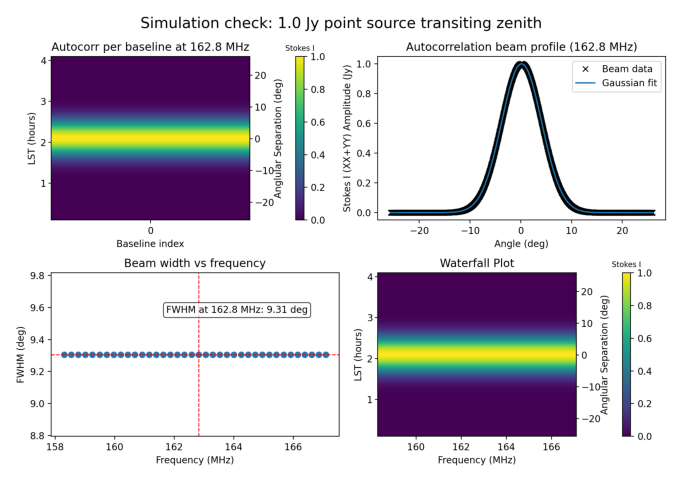

In [71]:
# Get beamcheck filenames
BEAMCHECK_YAML = run_dir / "obsparam_beamcheck.yaml"

if not BEAMCHECK_YAML.exists():
    print(f"WARNING: beamcheck YAML not found at {BEAMCHECK_YAML}.")
else:
    beamcheck_param = read_yaml(BEAMCHECK_YAML)

    filing = beamcheck_param["filing"]
    stem = filing["outfile_name"]
    beamcheck_dir = run_dir / filing["outdir"]

    beamcheck_sim = beamcheck_dir / (stem + "." + filing["output_format"])
    beamcheck_log = beamcheck_dir / (stem + ".log")
    beamcheck_plot = beamcheck_dir / (stem + ".png")

    print(beamcheck_log.read_text())

    img = mpimg.imread(beamcheck_plot)

    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis("off")

## UV-Plane Visibility Comparison

This cell compares visibilities from two simulation runs:

1. `file1`: Visibilities generated by running this notebook.  
2. `file2`: Visibilities generated from a previous pyuvsim run.

We extract data for a single timestamp, first frequency channel, and Stokes I.  
The visibilities are sorted by baseline to ensure consistent comparison.

**Purpose:**

- Verify that the notebook simulation reproduces the same results as the local run.  
- Check numerical consistency and reproducibility of the pyuvsim simulation.  
- Visualize the UV-plane amplitude and residuals:

Residual = |StokeI Vis2 - StokeI Vis1|

where Vis1 and Vis2 correspond to the notebook and local runs, respectively.


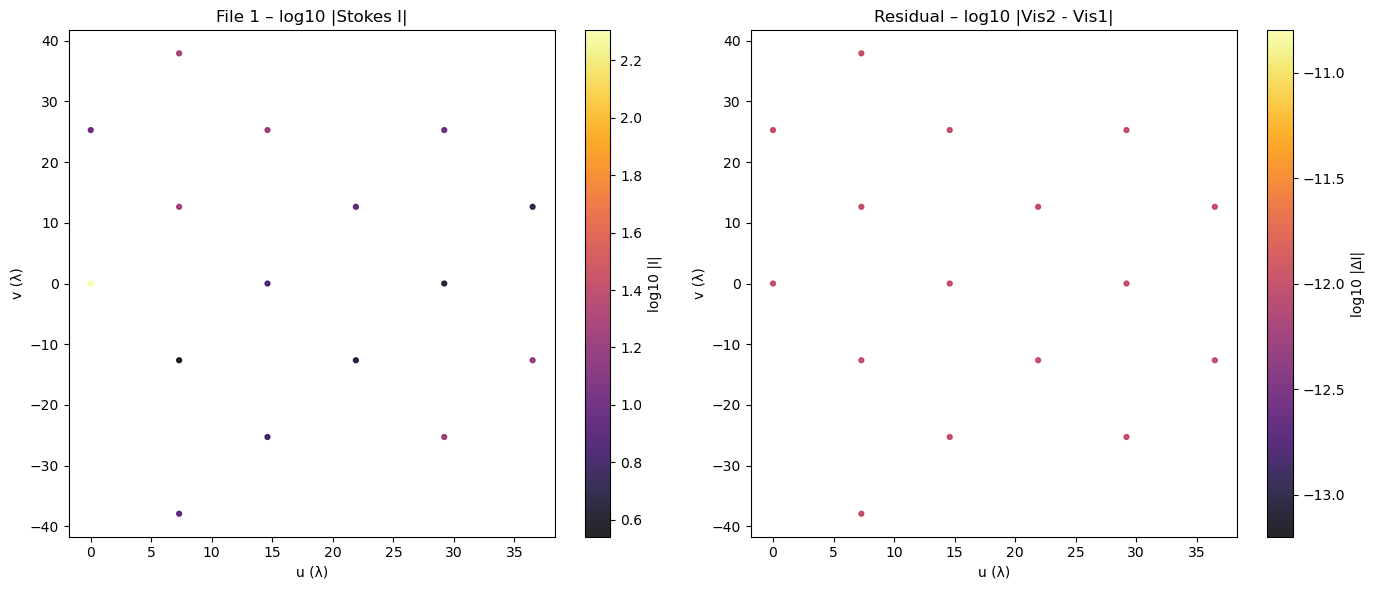

In [76]:
# Input visibility files
file1 = sim_path
file2 = sim_path

# Load UVData objects
uv1 = UVData()
uv2 = UVData()
uv1.read_uvh5(file1)
uv2.read_uvh5(file2)

# Get array dimensions
Nbl1, Nspw1, Nfreq1, Npol1 = unpack_shape(uv1.data_array)
Nbl2, Nspw2, Nfreq2, Npol2 = unpack_shape(uv2.data_array)

# Select first timestamp, first frequency, Stokes I
time_idx = 0
freq_idx = 0
pol_idx = 0  # Stokes I

# Create time masks
time_mask1 = uv1.time_array == uv1.time_array[time_idx]
time_mask2 = uv2.time_array == uv2.time_array[time_idx]

# Extract Stokes I visibilities
vis1_I = extract_vis(uv1, time_idx, pol_idx, freq_idx)
vis2_I = extract_vis(uv2, time_idx, pol_idx, freq_idx)

# Sort baselines consistently by (ant1, ant2) pairs
keys1 = np.array(
    list(zip(uv1.ant_1_array[time_mask1], uv1.ant_2_array[time_mask1])),
    dtype=[("a1", int), ("a2", int)],
)
keys2 = np.array(
    list(zip(uv2.ant_1_array[time_mask2], uv2.ant_2_array[time_mask2])),
    dtype=[("a1", int), ("a2", int)],
)

order1 = np.argsort(keys1, order=("a1", "a2"))
order2 = np.argsort(keys2, order=("a1", "a2"))

vis1_I = vis1_I[order1]
vis2_I = vis2_I[order2]

# Extract UV coordinates
uvw1 = uv1.uvw_array[time_mask1][order1, :2]
uvw2 = uv2.uvw_array[time_mask2][order2, :2]

# Compute residual
residual = np.abs(vis2_I) - np.abs(vis1_I)

# Log-scale for visualization
log_amp1 = np.log10(np.abs(vis1_I) + 1e-12)
log_res = np.log10(np.abs(residual) + 1e-12)

u1, v1 = uvw1[:, 0], uvw1[:, 1]

# Plot visibility amplitude and residual in UV plane
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# File 1 visibility amplitude
sc1 = axes[0].scatter(u1, v1, s=12, c=log_amp1, cmap="inferno", alpha=0.85)
axes[0].set_title("File 1 – log10 |Stokes I|")
axes[0].set_xlabel("u (λ)")
axes[0].set_ylabel("v (λ)")
plt.colorbar(sc1, ax=axes[0], label="log10 |I|")

# Residual
sc2 = axes[1].scatter(u1, v1, s=12, c=log_res, cmap="inferno", alpha=0.85)
axes[1].set_title("Residual – log10 |Vis2 - Vis1|")
axes[1].set_xlabel("u (λ)")
axes[1].set_ylabel("v (λ)")
plt.colorbar(sc2, ax=axes[1], label="log10 |ΔI|")

plt.tight_layout()
plt.show()

## Time-Baseline Waterfall Plot

Visualize visibility amplitudes as a function of time and baseline
for a single frequency channel.

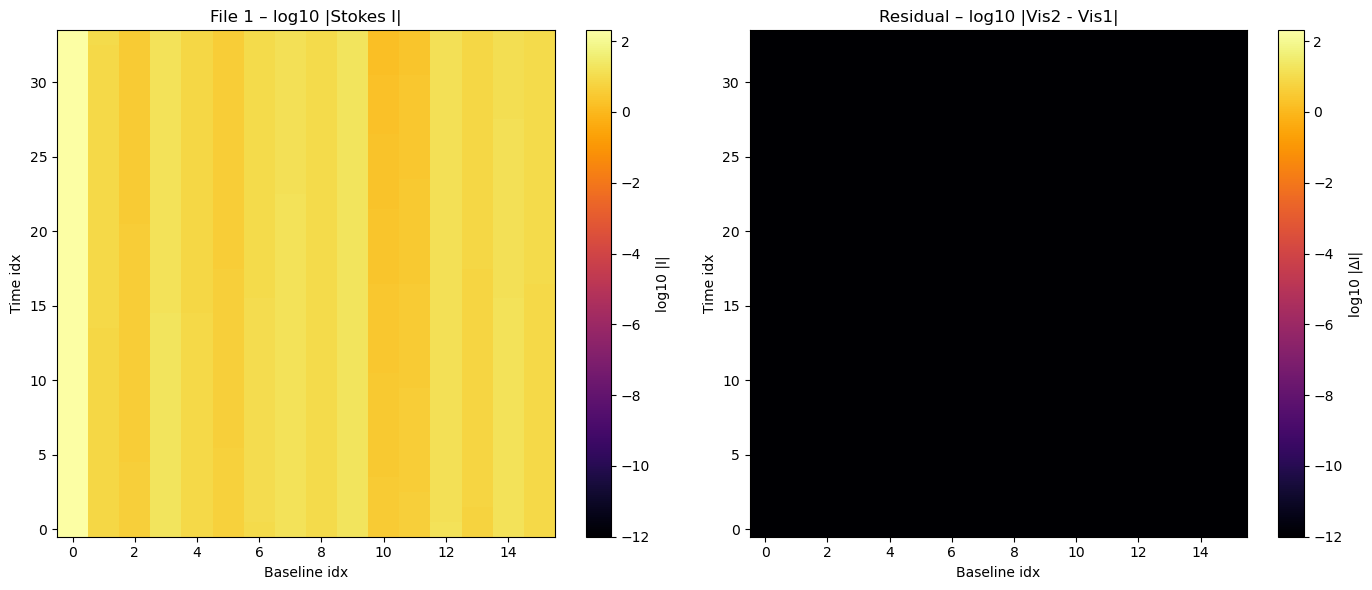

In [77]:
# Choose frequency index and Stokes I
freq_idx = 0
pol_idx = 0

# Extract all time samples for selected frequency
vis1_time = (
    uv1.data_array[:, 0, freq_idx, pol_idx]
    if uv1.data_array.ndim == 4
    else uv1.data_array[:, freq_idx, pol_idx]
)
vis2_time = (
    uv2.data_array[:, 0, freq_idx, pol_idx]
    if uv2.data_array.ndim == 4
    else uv2.data_array[:, freq_idx, pol_idx]
)

# Reshape into (time, baseline) matrix
times = np.unique(uv1.time_array)
Ntime = len(times)
Nbl = len(vis1_time) // Ntime

vis1_mat = vis1_time.reshape(Ntime, Nbl)
vis2_mat = vis2_time.reshape(Ntime, Nbl)
residual_mat = np.abs(vis2_mat - vis1_mat)

# Log scaling
eps_val = 1e-12
vis1_log = np.log10(np.abs(vis1_mat) + eps_val)
res_log = np.log10(residual_mat + eps_val)

# Common color scale
clim = [min(vis1_log.min(), res_log.min()), max(vis1_log.max(), res_log.max())]

# Plot waterfall
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# File 1
im1 = axes[0].imshow(
    vis1_log,
    aspect="auto",
    origin="lower",
    cmap="inferno",
    vmin=clim[0],
    vmax=clim[1],
)
axes[0].set_title("File 1 – log10 |Stokes I|")
axes[0].set_xlabel("Baseline idx")
axes[0].set_ylabel("Time idx")
plt.colorbar(im1, ax=axes[0], label="log10 |I|")

# Residual
im2 = axes[1].imshow(
    res_log,
    aspect="auto",
    origin="lower",
    cmap="inferno",
    vmin=clim[0],
    vmax=clim[1],
)
axes[1].set_title("Residual – log10 |Vis2 - Vis1|")
axes[1].set_xlabel("Baseline idx")
axes[1].set_ylabel("Time idx")
plt.colorbar(im2, ax=axes[1], label="log10 |ΔI|")

plt.tight_layout()
plt.show()

## Frequency-Baseline Waterfall Plot

Visualize visibility amplitudes as a function of frequency and baseline  
for a single timestamp.

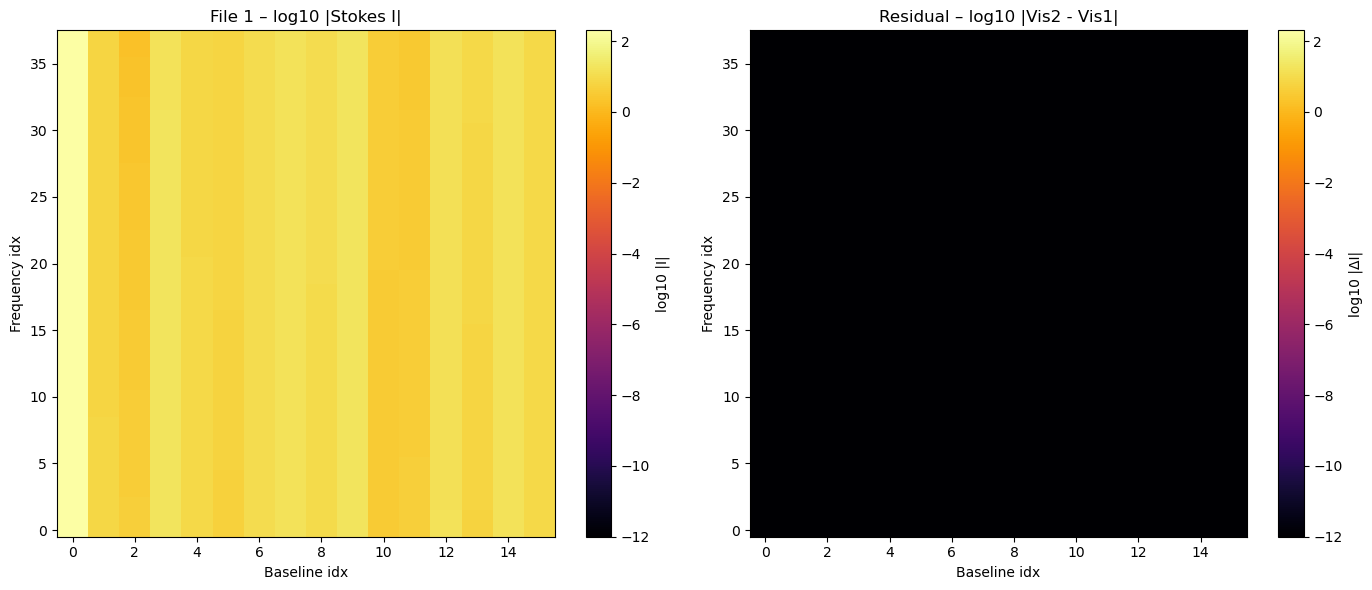

In [78]:
# Choose time index and Stokes I
time_idx = 0
pol_idx = 0

# Extract frequency slices (shape: Nbl x Nfreq)
vis1_freq = extract_vis(uv1, time_idx, pol_idx)
vis2_freq = extract_vis(uv2, time_idx, pol_idx)

# Sort baselines consistently
keys1 = np.array(
    list(
        zip(
            uv1.ant_1_array[uv1.time_array == uv1.time_array[time_idx]],
            uv1.ant_2_array[uv1.time_array == uv1.time_array[time_idx]],
        )
    ),
    dtype=[("a1", int), ("a2", int)],
)
keys2 = np.array(
    list(
        zip(
            uv2.ant_1_array[uv2.time_array == uv2.time_array[time_idx]],
            uv2.ant_2_array[uv2.time_array == uv2.time_array[time_idx]],
        )
    ),
    dtype=[("a1", int), ("a2", int)],
)

order1 = np.argsort(keys1, order=("a1", "a2"))
order2 = np.argsort(keys2, order=("a1", "a2"))

vis1_freq = vis1_freq[order1, :]
vis2_freq = vis2_freq[order2, :]

# Compute residual
residual_freq = np.abs(vis2_freq - vis1_freq)

# Log scaling
eps_val = 1e-12
vis1_log = np.log10(np.abs(vis1_freq) + eps_val)
res_log = np.log10(residual_freq + eps_val)

# Common color scale
clim = [min(vis1_log.min(), res_log.min()), max(vis1_log.max(), res_log.max())]

# Plot frequency waterfall
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# File 1
im1 = axes[0].imshow(
    vis1_log.T,
    aspect="auto",
    origin="lower",
    cmap="inferno",
    vmin=clim[0],
    vmax=clim[1],
)
axes[0].set_title("File 1 – log10 |Stokes I|")
axes[0].set_xlabel("Baseline idx")
axes[0].set_ylabel("Frequency idx")
plt.colorbar(im1, ax=axes[0], label="log10 |I|")

# Residual
im2 = axes[1].imshow(
    res_log.T,
    aspect="auto",
    origin="lower",
    cmap="inferno",
    vmin=clim[0],
    vmax=clim[1],
)
axes[1].set_title("Residual – log10 |Vis2 - Vis1|")
axes[1].set_xlabel("Baseline idx")
axes[1].set_ylabel("Frequency idx")
plt.colorbar(im2, ax=axes[1], label="log10 |ΔI|")

plt.tight_layout()
plt.show()